# Parte 2 — Sensibilidad (OLS, bootstrap, Sobol, profiling)


| Pieza | Rol |
|-------|-----|
| `data/sinteticos.py` | Genera `series_corta_balance.csv` (y variantes con ruido) |
| `src/model.py` | `run_batch` / `saint_venant_1d` con **Q aguas arriba del CSV** + `q_lat_m3s` |
| Este notebook | OLS, bootstrap, Sobol, métricas, figuras, profiling |

**Parámetros calibrables (como en el 01):** `n`, `S0`, `B_w`  
**Observación:** `Q_downstream_m3s` del CSV  
**Salida del modelo:** `Q_sim = max(Q_solver, 0)` en x = L (solo en este notebook; el solver interno no cambia)  
**Partición:** warm-up 3600 s · 60 % cal · 30 % val (sobre índices post warm-up)

**Funciones objetivo:**
- OLS: min Σ(Q_obs − Q_sim)² en calibración
- Métricas: NSE, KGE, RMSE (cal / val)
- Sobol: Y configurable → `1−NSE`, `RMSE` o `1−KGE` (post warm-up)

**5 suposiciones del modelo de errores:**
1. Aditivos — R vs Q_sim sin patrón sistemático  
2. Media cero — mean(R) ≈ 0  
3. Varianza constante — R vs tiempo sin embudo claro  
4. No correlados — suficientes cruces de signo en R[i]·R[i+1]  
5. Normalidad — histograma de R vs curva gaussiana

In [12]:
%load_ext autoreload
%autoreload 2

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from SALib.analyze import sobol as sobol_analyze
from SALib.sample import saltelli
from scipy.optimize import least_squares
from scipy.stats import t as student_t

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import importlib
import src.model as _model_mod

importlib.reload(_model_mod)
from src.model import run_batch, saint_venant_1d

if not hasattr(saint_venant_1d, "__call__") or not hasattr(_model_mod, "run_batch"):
    raise ImportError(
        "src/model.py debe definir saint_venant_1d y run_batch. "
        "Reinicie el kernel (Kernel → Restart) y vuelva a ejecutar."
    )
print("model.py OK:", _model_mod.__file__)

_spec = importlib.util.spec_from_file_location("sinteticos", ROOT / "data" / "sinteticos.py")
sinteticos = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(sinteticos)

PARAM_NAMES = ["n", "S0", "B_w"]
PARAMS_TRUE = [sinteticos.N_MANN, sinteticos.S0, sinteticos.B_W]
L_CANAL = sinteticos.L
NX = 100
WARMUP_SECONDS = 3600.0
BOUNDS_LO = [0.01, 0.0001, 20.0]
BOUNDS_HI = [0.06, 0.005, 80.0]
CAL_FRAC, VAL_FRAC = 0.60, 0.30
ALPHA, DH = 0.05, 1e-4

FIG = ROOT / "figures"
DATA = ROOT / "data" / "synthetic"
REPORTS = ROOT / "reports"
for d in (FIG, DATA, REPORTS):
    d.mkdir(parents=True, exist_ok=True)

FAST = True
USE_LONG_SERIES = False
USE_NOISY_CSV = False
NBOOT = 0 if FAST else 200
SOBOL_N = 64 if FAST else 512
SOBOL_METRIC = "nse"
N_JOBS = 1
RUN_PROFILING = not FAST
COMPUTE_SSC = not FAST

PROBLEM = {"num_vars": 3, "names": PARAM_NAMES, "bounds": list(zip(BOUNDS_LO, BOUNDS_HI))}
print("ROOT:", ROOT, "| FAST:", FAST)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
model.py OK: D:\descagas\proyecto-hidrosistemas\src\model.py
ROOT: D:\descagas\proyecto-hidrosistemas | FAST: True


In [13]:
if USE_LONG_SERIES:
    csv_name = "series_larga_ruido.csv" if USE_NOISY_CSV else "series_larga_balance.csv"
else:
    csv_name = "series_corta_ruido.csv" if USE_NOISY_CSV else "series_corta_balance.csv"

csv_path = DATA / csv_name
if not csv_path.exists():
    print("Generando CSV con data/sinteticos.py ...")
    sinteticos.generate(str(DATA))

df = pd.read_csv(csv_path, parse_dates=["datetime"])
t_sec = (df["datetime"] - df["datetime"].iloc[0]).dt.total_seconds().to_numpy(dtype=float)
q_up = df["Q_upstream_m3s"].to_numpy(dtype=float)
q_lat = df["q_lat_m3s"].to_numpy(dtype=float) if "q_lat_m3s" in df.columns else None
q_obs = df["Q_downstream_m3s"].to_numpy(dtype=float)
nt = len(df)

mask_warm = t_sec < WARMUP_SECONDS
idx_post = np.where(~mask_warm)[0]
n_post = len(idx_post)
n_cal = max(1, int(CAL_FRAC * n_post))
n_val = max(1, int(VAL_FRAC * n_post))
n_cal = min(n_cal, n_post - n_val)
i_cal = idx_post[:n_cal]
i_val = idx_post[n_cal : n_cal + n_val]

mask_cal = np.zeros(nt, dtype=bool)
mask_val = np.zeros(nt, dtype=bool)
mask_cal[i_cal] = True
mask_val[i_val] = True
mask_fit = mask_cal
mask_sobol = ~mask_warm

print(f"CSV: {csv_name}  nt={nt}")
print(f"warm-up={mask_warm.sum()}  cal={mask_cal.sum()}  val={mask_val.sum()}")

CSV: series_corta_balance.csv  nt=500
warm-up=4  cal=297  val=148


In [14]:
def simulate_outlet(params):
    """CSV como Q aguas arriba + q_lat; caudal en x=L con Q >= 0 para comparar con Q_obs."""
    p = list(map(float, params))
    q = np.asarray(
        saint_venant_1d(
            p,
            q_upstream=q_up,
            time_seconds=t_sec,
            L=L_CANAL,
            nx=NX,
            q_lat=q_lat,
        ),
        dtype=float,
    )
    return np.maximum(q, 0.0)


def nse(obs, sim, m):
    o, s = obs[m], sim[m]
    den = float(np.sum((o - np.mean(o)) ** 2))
    return 1.0 if den < 1e-12 else float(1.0 - np.sum((o - s) ** 2) / den)


def kge(obs, sim, m):
    o, s = obs[m], sim[m]
    if np.std(o) < 1e-12 or np.std(s) < 1e-12:
        return -np.inf
    r = float(np.corrcoef(o, s)[0, 1])
    return float(1.0 - np.sqrt((r - 1) ** 2 + (np.std(s) / np.std(o) - 1) ** 2 + (np.mean(s) / np.mean(o) - 1) ** 2))


def rmse_m(obs, sim, m):
    return float(np.sqrt(np.mean((obs[m] - sim[m]) ** 2)))


def metrics_table(obs, sim):
    rows = []
    for label, m in [
        ("calibracion", mask_cal),
        ("validacion", mask_val),
        ("post_warmup", mask_sobol),
    ]:
        if m.sum() < 2:
            continue
        rows.append({
            "periodo": label,
            "NSE": nse(obs, sim, m),
            "KGE": kge(obs, sim, m),
            "RMSE_m3s": rmse_m(obs, sim, m),
        })
    return pd.DataFrame(rows)


def sobol_y(params, metric=SOBOL_METRIC):
    q = simulate_outlet(params)
    if metric == "rmse":
        return rmse_m(q_obs, q, mask_sobol)
    if metric == "kge":
        return 1.0 - kge(q_obs, q, mask_sobol)
    return 1.0 - nse(q_obs, q, mask_sobol)


q_ref = simulate_outlet(PARAMS_TRUE)
display(metrics_table(q_obs, q_ref))

,periodo,NSE,KGE,RMSE_m3s
0,calibracion,-0.534702,-0.331787,79.822806
1,validacion,-2.064354,-0.361910,102.711496
2,post_warmup,-0.599466,-0.295157,83.890588


## OLS + bootstrap (periodo calibración)

In [15]:
p = len(PARAM_NAMES)


def ols_res(pp):
    return q_obs[mask_fit] - simulate_outlet(pp)[mask_fit]


q0 = np.array(PARAMS_TRUE) * np.array([1.05, 0.98, 1.02])
ols = least_squares(ols_res, q0, bounds=(BOUNDS_LO, BOUNDS_HI), method="trf")
q_ols = ols.x
res_fit = ols.fun
jac = ols.jac
n_fit = mask_fit.sum()
sigma = float(np.sqrt((res_fit @ res_fit) / max(n_fit - p, 1)))
q_pred = simulate_outlet(q_ols)
res_all = q_obs - q_pred

cond_j = float(np.linalg.cond(jac.T @ jac))
ols_ok = cond_j < 1e8
print(f"OLS | cond(J'J)={cond_j:.2e} | sigma={sigma:.4f} | IC OLS fiables={ols_ok}")
print(dict(zip(PARAM_NAMES, np.round(q_ols, 5))))

m_ols = metrics_table(q_obs, q_pred)
m_ols.to_csv(DATA / "metricas_ols_cal_val.csv", index=False)
display(m_ols)

OLS | cond(J'J)=2.53e+13 | sigma=63.7619 | IC OLS fiables=False
{'n': np.float64(0.02517), 'S0': np.float64(0.005), 'B_w': np.float64(79.9121)}


,periodo,NSE,KGE,RMSE_m3s
0,calibracion,0.030645,0.150091,63.439017
1,validacion,-0.598909,0.245317,74.192757
2,post_warmup,0.051504,0.237517,64.601632


In [16]:
if ols_ok:
    cov = sigma ** 2 * np.linalg.pinv(jac.T @ jac + 1e-10 * np.eye(p))
    se = np.sqrt(np.maximum(np.diag(cov), 0))
    tcrit = float(student_t.ppf(1 - ALPHA / 2, n_fit - p))
    ci_ols = np.column_stack((q_ols - tcrit * se, q_ols + tcrit * se))
    corr = (np.diag(1 / np.maximum(se, 1e-30))) @ cov @ (np.diag(1 / np.maximum(se, 1e-30)))
else:
    se = np.full(p, np.nan)
    ci_ols = np.full((p, 2), np.nan)
    corr = np.full((p, p), np.nan)

ci_boot = None
if NBOOT > 0:
    print(f"Bootstrap {NBOOT}...")
    rng = np.random.default_rng(42)
    q_boot = np.zeros((NBOOT, p))
    yhat = q_pred[mask_fit]
    for i in range(NBOOT):
        y_b = yhat + res_fit[rng.integers(0, n_fit, n_fit)]

        def rb(pp):
            return y_b - simulate_outlet(pp)[mask_fit]

        q_boot[i] = least_squares(rb, q_ols, bounds=(BOUNDS_LO, BOUNDS_HI), method="trf").x
    qs = np.sort(q_boot, 0)
    Lb, Ub = int(ALPHA / 2 * NBOOT), int((1 - ALPHA / 2) * NBOOT)
    ci_boot = np.column_stack((qs[Lb], qs[Ub]))

tab = []
for i, nm in enumerate(PARAM_NAMES):
    row = {"parametro": nm, "verdadero": PARAMS_TRUE[i], "ols": q_ols[i], "SE": se[i]}
    if ols_ok:
        row["CI_ols_inf"], row["CI_ols_sup"] = ci_ols[i]
    if ci_boot is not None:
        row["CI_boot_inf"], row["CI_boot_sup"] = ci_boot[i]
    tab.append(row)
pd.DataFrame(tab).to_csv(DATA / "parametros_ols_sensibilidad.csv", index=False)
pd.DataFrame(tab)

,parametro,verdadero,ols,SE
0,n,0.035,0.025171,NaN
1,S0,0.001,0.005000,NaN
2,B_w,50.000,79.912098,NaN


In [17]:
from scipy.stats import norm

if COMPUTE_SSC:
    ssc = np.zeros((nt, p))
    y0 = q_pred.copy()
    for i in range(p):
        pt = q_ols.copy()
        pt[i] *= 1 + DH
        ssc[:, i] = (simulate_outlet(pt) - y0) / DH
    pd.DataFrame({
        "parametro": PARAM_NAMES,
        "SSC_max_abs": [float(np.max(np.abs(ssc[:, j]))) for j in range(p)],
    }).to_csv(DATA / "ssc_resumen.csv", index=False)
else:
    ssc = None
    print("SSC omitido (FAST=True).")

# --- Validacion 5 suposiciones (periodo calibracion) ---
R = res_all[mask_fit]
Yp = q_pred[mask_fit]
t_cal = t_sec[mask_fit]

# Sup.2 media cero
mean_r = float(np.mean(R))
std_r = float(np.std(R))
mean_ok = abs(mean_r) < 0.05 * max(std_r, 1e-9)

# Sup.4 no correlacion (criterio de cruces)
cross = R[1:] * R[:-1]
n_cross = int(np.sum(np.sign(cross) < 0))
min_cross = (len(R) + 1) / 2
uncorr_ok = n_cross >= min_cross

# Sup.3 varianza (visual; flag si var(R) crece con |Yp| de forma fuerte)
# Sup.5 normalidad (visual + comparacion cualitativa)

msgs = [
    "=== 5 suposiciones (periodo calibracion) ===",
    f"Sup.1 Aditivos: revisar figura sup01_residuales_vs_prediccion.png",
    f"Sup.2 Media cero: mean(R)={mean_r:.3e} -> {'OK' if mean_ok else 'REVISAR'}",
    f"Sup.3 Var constante: revisar sup03_residuales_vs_tiempo.png",
    f"Sup.4 No correlacion: {n_cross} cruces (min {min_cross:.0f}) -> {'OK' if uncorr_ok else 'REVISAR'}",
    f"Sup.5 Normalidad: revisar sup05_histograma_residuales.png",
    f"Identificabilidad cond(J'J)={cond_j:.2e} -> {'OK' if ols_ok else 'REVISAR (usar IC bootstrap)'}",
]
(DATA / "suposiciones_errores.txt").write_text("\n".join(msgs), encoding="utf-8")
print("\n".join(msgs))

SSC omitido (FAST=True).
=== 5 suposiciones (periodo calibracion) ===
Sup.1 Aditivos: revisar figura sup01_residuales_vs_prediccion.png
Sup.2 Media cero: mean(R)=3.565e+01 -> REVISAR
Sup.3 Var constante: revisar sup03_residuales_vs_tiempo.png
Sup.4 No correlacion: 2 cruces (min 149) -> REVISAR
Sup.5 Normalidad: revisar sup05_histograma_residuales.png
Identificabilidad cond(J'J)=2.53e+13 -> REVISAR (usar IC bootstrap)


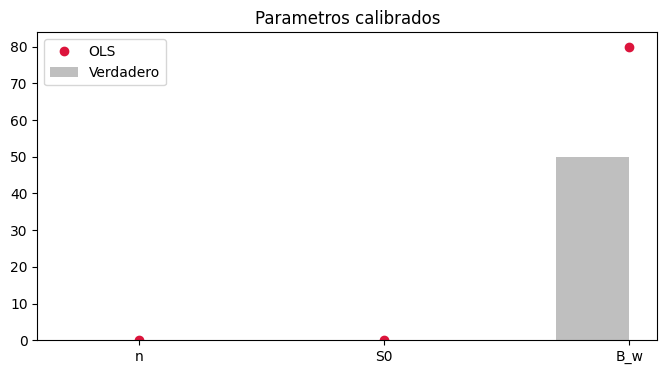

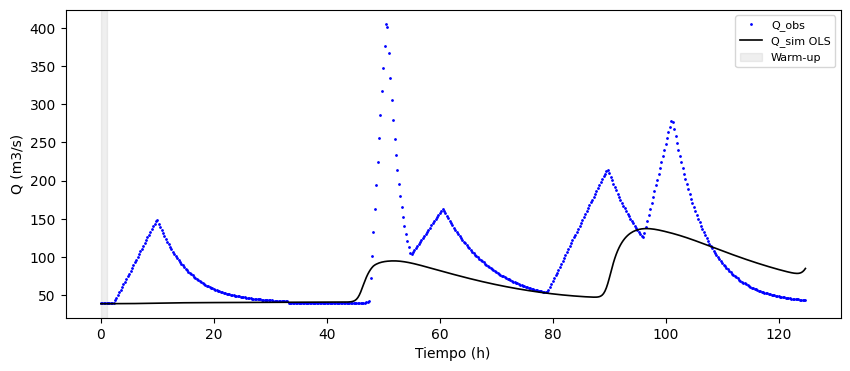

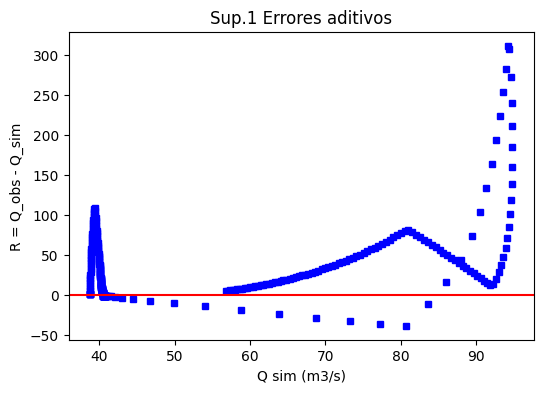

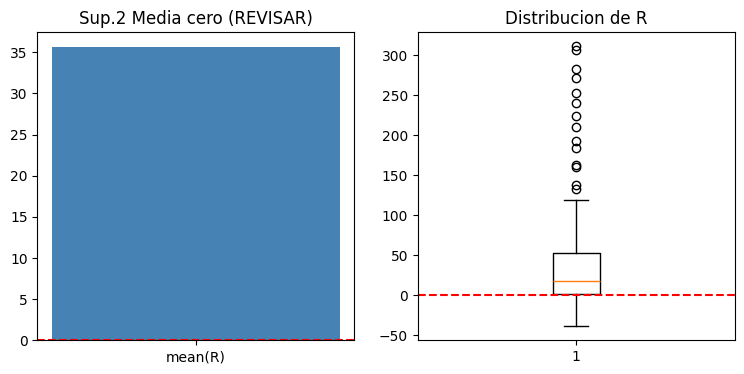

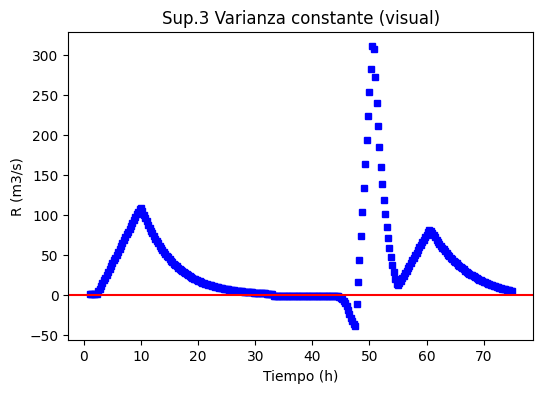

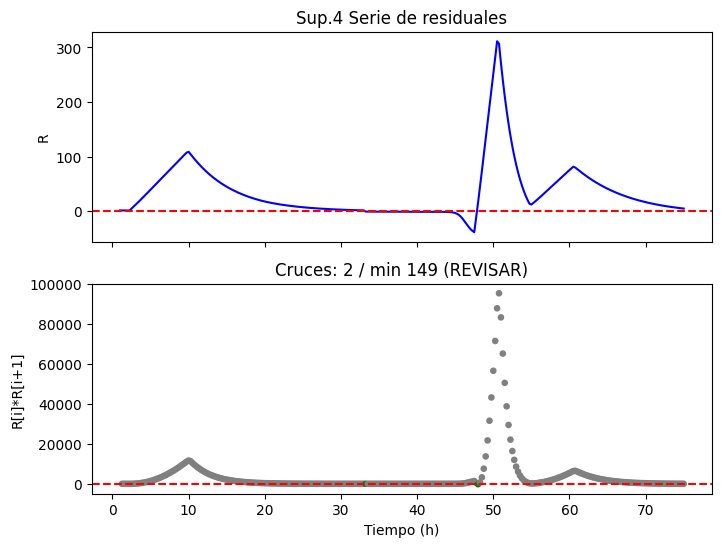

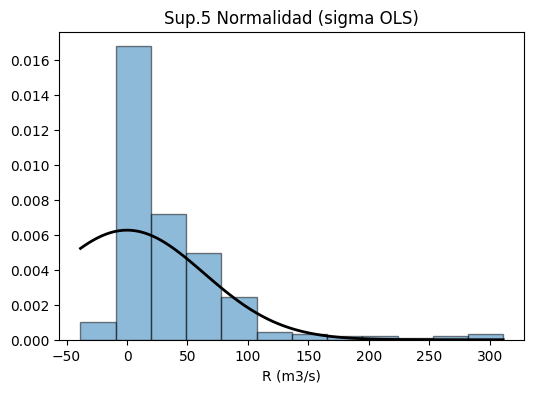

In [18]:
t_h = t_sec / 3600.0
xv = np.arange(p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xv - 0.15, PARAMS_TRUE, 0.3, label="Verdadero", color="0.75")
ax.plot(xv, q_ols, "o", color="crimson", label="OLS")
if ols_ok and np.all(np.isfinite(ci_ols)):
    ax.errorbar(xv, q_ols, yerr=[q_ols - ci_ols[:, 0], ci_ols[:, 1] - q_ols], fmt="none", color="crimson", capsize=4)
if ci_boot is not None:
    ax.errorbar(xv, q_ols, yerr=[q_ols - ci_boot[:, 0], ci_boot[:, 1] - q_ols], fmt="none", ecolor="navy", capsize=3, label="IC bootstrap")
ax.set_xticks(xv)
ax.set_xticklabels(PARAM_NAMES)
ax.set_title("Parametros calibrados")
ax.legend()
fig.savefig(FIG / "parametros_intervalos_confianza.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_h, q_obs, "b.", ms=2, label="Q_obs")
ax.plot(t_h, q_pred, "k-", lw=1.2, label="Q_sim OLS")
ax.axvspan(0, WARMUP_SECONDS / 3600, color="gray", alpha=0.12, label="Warm-up")
ax.legend(fontsize=8)
ax.set_xlabel("Tiempo (h)")
ax.set_ylabel("Q (m3/s)")
fig.savefig(FIG / "intervalos_confianza_prediccion.png", dpi=150)
plt.show()

# Sup.1 aditivos
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Yp, R, "bs", ms=4)
ax.axhline(0, color="r")
ax.set_xlabel("Q sim (m3/s)")
ax.set_ylabel("R = Q_obs - Q_sim")
ax.set_title("Sup.1 Errores aditivos")
fig.savefig(FIG / "sup01_residuales_vs_prediccion.png", dpi=150)
plt.show()

# Sup.2 media cero
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(["mean(R)"], [mean_r], color="steelblue")
axes[0].axhline(0, color="r", ls="--")
axes[0].set_title(f"Sup.2 Media cero ({'OK' if mean_ok else 'REVISAR'})")
axes[1].boxplot(R, vert=True)
axes[1].axhline(0, color="r", ls="--")
axes[1].set_title("Distribucion de R")
fig.savefig(FIG / "sup02_media_error_cero.png", dpi=150)
plt.show()

# Sup.3 varianza constante
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_cal / 3600, R, "bs", ms=4)
ax.axhline(0, color="r")
ax.set_xlabel("Tiempo (h)")
ax.set_ylabel("R (m3/s)")
ax.set_title("Sup.3 Varianza constante (visual)")
fig.savefig(FIG / "sup03_residuales_vs_tiempo.png", dpi=150)
plt.show()

# Sup.4 no correlacion
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t_cal / 3600, R, "b-")
axes[0].axhline(0, color="r", ls="--")
axes[0].set_ylabel("R")
axes[0].set_title("Sup.4 Serie de residuales")
is_cross = np.sign(cross) < 0
axes[1].scatter(t_cal[1:] / 3600, cross, c=np.where(is_cross, "green", "gray"), s=14)
axes[1].axhline(0, color="r", ls="--")
axes[1].set_xlabel("Tiempo (h)")
axes[1].set_ylabel("R[i]*R[i+1]")
axes[1].set_title(f"Cruces: {n_cross} / min {min_cross:.0f} ({'OK' if uncorr_ok else 'REVISAR'})")
fig.savefig(FIG / "sup04_errores_no_correlacionados.png", dpi=150)
plt.show()

# Sup.5 normalidad
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(R, bins=12, density=True, alpha=0.5, edgecolor="k")
xnorm = np.linspace(R.min(), R.max(), 100)
ax.plot(xnorm, norm.pdf(xnorm, 0, sigma), "k-", lw=2)
ax.set_xlabel("R (m3/s)")
ax.set_title("Sup.5 Normalidad (sigma OLS)")
fig.savefig(FIG / "sup05_histograma_residuales.png", dpi=150)
plt.show()

if np.all(np.isfinite(corr)):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(p))
    ax.set_yticks(range(p))
    ax.set_xticklabels(PARAM_NAMES, rotation=45)
    ax.set_yticklabels(PARAM_NAMES)
    fig.colorbar(im, ax=ax)
    ax.set_title("Correlacion parametros OLS")
    fig.savefig(FIG / "correlacion_parametros.png", dpi=150)
    plt.show()

if ssc is not None:
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    axes[0].plot(t_h, q_pred, "k-")
    axes[0].set_ylabel("Q (m3/s)")
    for j, nm in enumerate(PARAM_NAMES):
        axes[1].plot(t_h, ssc[:, j], "--", label=nm)
    axes[1].legend(fontsize=8)
    axes[1].set_xlabel("Tiempo (h)")
    fig.savefig(FIG / "ssc_hidrograma.png", dpi=150)
    plt.show()

## Sobol global (SALib)

Y=1-NSE | evaluaciones ~ 320


C:\Users\laura\AppData\Local\Temp\ipykernel_21348\1488704216.py:4: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  samples = saltelli.sample(PROBLEM, SOBOL_N, calc_second_order=False)


,parametro,S1,S1_conf,ST,ST_conf
0,n,0.0,99084.7261,0.0,0.8492
1,S0,0.0,52394.2563,0.0,0.2198
2,B_w,-0.0,13172.7548,0.0,0.0104


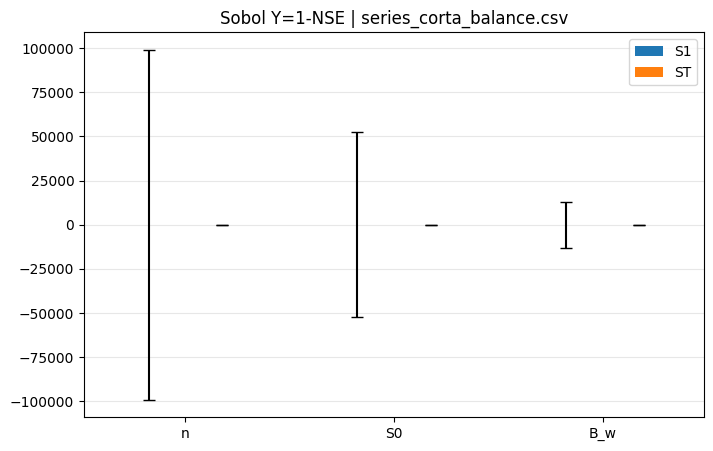

In [19]:
labels = {"nse": "Y=1-NSE", "rmse": "Y=RMSE", "kge": "Y=1-KGE"}
print(labels[SOBOL_METRIC], "| evaluaciones ~", SOBOL_N * (PROBLEM["num_vars"] + 2))

samples = saltelli.sample(PROBLEM, SOBOL_N, calc_second_order=False)
if N_JOBS == 1:
    Y = np.array([sobol_y(row, SOBOL_METRIC) for row in samples])
else:
    Y = np.array(Parallel(n_jobs=N_JOBS)(delayed(sobol_y)(row, SOBOL_METRIC) for row in samples))

Si = sobol_analyze.analyze(PROBLEM, Y, calc_second_order=False, conf_level=0.95, print_to_console=False)
sobol_df = pd.DataFrame({"parametro": PARAM_NAMES, "S1": Si["S1"], "S1_conf": Si["S1_conf"], "ST": Si["ST"], "ST_conf": Si["ST_conf"]})
sobol_df.to_csv(DATA / "sobol_indices.csv", index=False)
display(sobol_df.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
bw = 0.35
ax.bar(xv - bw / 2, Si["S1"], bw, yerr=Si["S1_conf"], capsize=4, label="S1")
ax.bar(xv + bw / 2, Si["ST"], bw, yerr=Si["ST_conf"], capsize=4, label="ST")
ax.set_xticks(xv)
ax.set_xticklabels(PARAM_NAMES)
ax.set_title(f"Sobol {labels[SOBOL_METRIC]} | {csv_name}")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.savefig(FIG / "sobol_indices.png", dpi=150)
plt.show()

## Profiling (ydata-profiling)

In [20]:
if RUN_PROFILING:
    from ydata_profiling import ProfileReport

    prof = df[["datetime", "Q_upstream_m3s", "q_lat_m3s", "Q_downstream_m3s", "h_outlet_m"]].copy()
    prof["Q_sim_ols"] = q_pred
    prof["residual"] = prof["Q_downstream_m3s"] - prof["Q_sim_ols"]
    prof["periodo"] = np.where(mask_warm, "warmup", np.where(mask_cal, "calibracion", "validacion"))
    out = REPORTS / "profile_latest.html"
    ProfileReport(prof, title="Sensibilidad — serie sintetica", minimal=True).to_file(out)
    print("Reporte:", out)
else:
    print("Profiling omitido (FAST=True). USE RUN_PROFILING=True para informe final.")

Profiling omitido (FAST=True). USE RUN_PROFILING=True para informe final.
